<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica_7_PROCSIN/blob/main/Quest%C3%A3o%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### Questão 2
Para as respostas de módulo mostradas na figura (da Prática 7), derive a resposta ao impulso do filtro ideal. Em seguida, projete um filtro FIR de ordem $M \in \{50, 100\}$ utilizando as janelas retangular, triangular, Hamming, Hann e Blackman. Apresente a resposta ao impulso, o diagrama de polos e zeros e a resposta em frequência dos filtros projetados. Comente os resultados obtidos.


2. Para as respostas de módulo mostrada na figura abaixo, derive a resposta ao impulso do filtro ideal. Em seguida, projete um filtro FIR de ordem M ∈ {50, 100} utilizando as janelas retangular, triangular, Hamming, Hann e Blackman. Apresente a resposta ao impulso, o diagrama de polos e zeros e a resposta em frequência dos filtros projetados. Comente os resultados obtidos.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Definição dos parâmetros
ordens = [50, 100]

# Função para a janela triangular
def triangular_window(M):
    n = np.arange(M + 1)
    return 1 - np.abs((n - M/2)/(M/2))

# Cálculo da resposta ao impulso ideal h_id[n]
# Nota: A fórmula abaixo deriva da transformada inversa da resposta em frequência ideal
def calcular_h_ideal(M):
    n = np.arange(-M//2, M//2 + 1)
    h_ideal = np.zeros(len(n))
    for i, ni in enumerate(n):
        if ni == 0:
            h_ideal[i] = 3/8 # Valor central derivado
        else:
            h_ideal[i] = (np.sin(np.pi*ni/2)/(np.pi*ni) + 4*(np.cos(np.pi*ni/4)-1)/(np.pi**2 * ni**2))
    return n, h_ideal

In [28]:
filtros = {}
for M in ordens:
    n, h_ideal = calcular_h_ideal(M)
    janelas = {
        'Retangular': np.ones(M+1),
        'Triangular': triangular_window(M),
        'Hamming': np.hamming(M+1),
        'Hann': np.hanning(M+1),
        'Blackman': np.blackman(M+1)
    }
    filtros[M] = {nome: h_ideal * j for nome, j in janelas.items()}

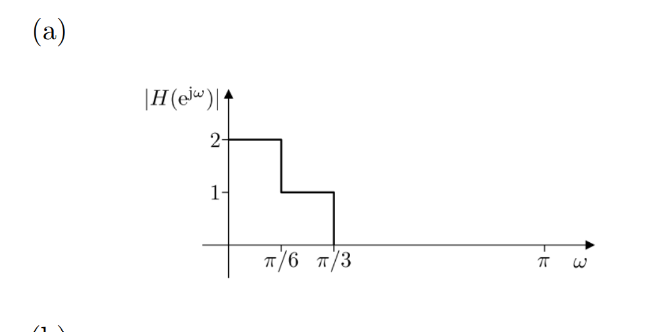

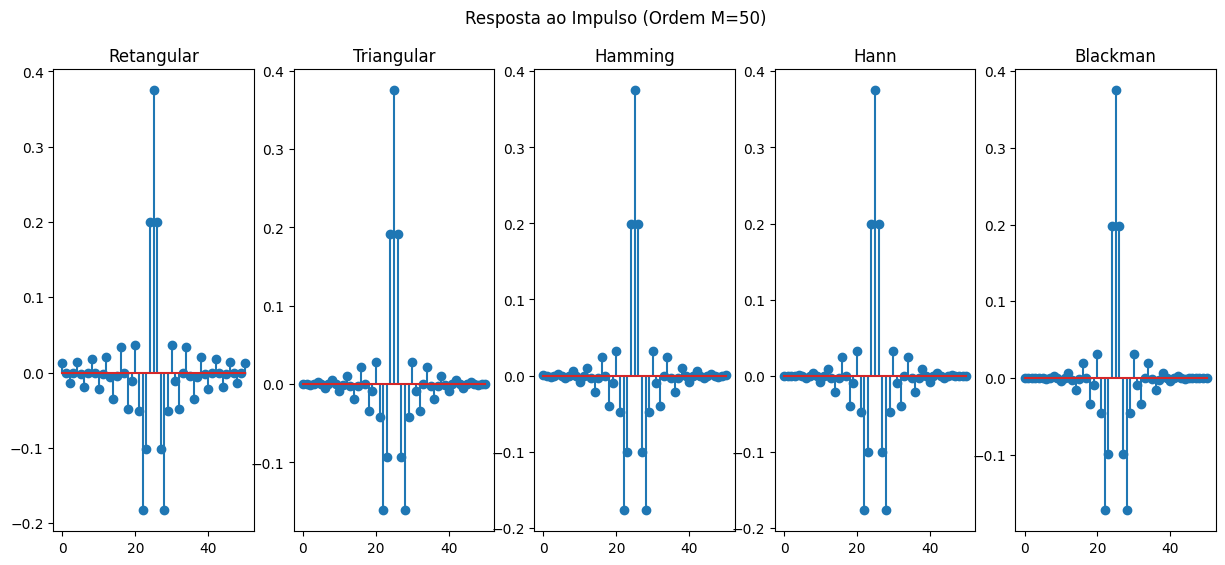

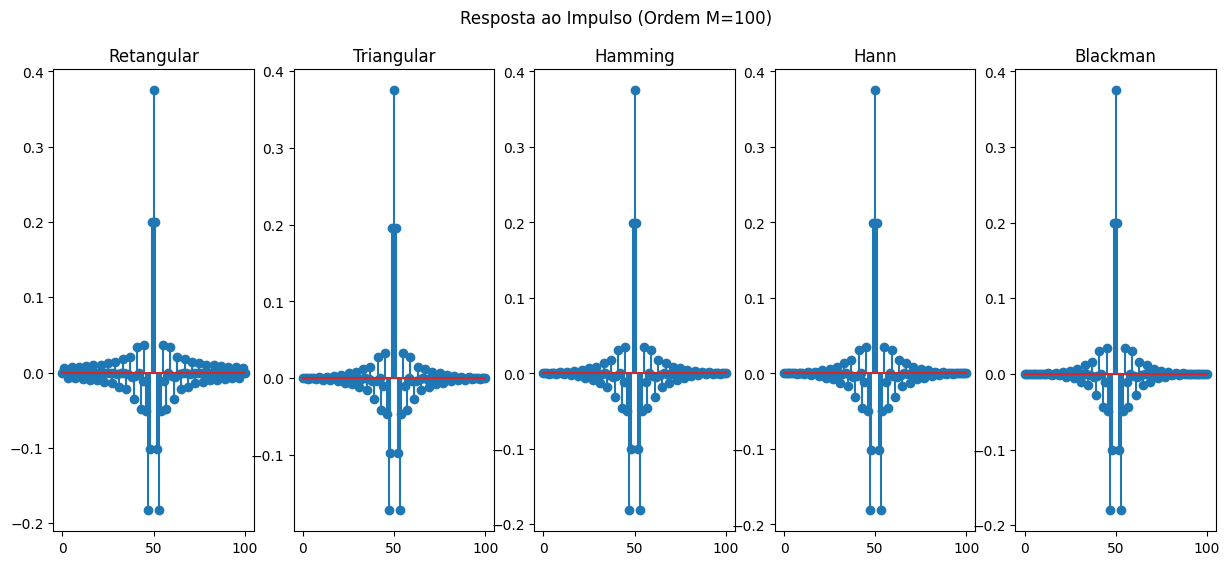

In [29]:
for M in ordens:
    plt.figure(figsize=(15, 6))
    for i, (nome, h) in enumerate(filtros[M].items(), 1):
        plt.subplot(1, 5, i)
        plt.stem(h)
        plt.title(nome)
    plt.suptitle(f'Resposta ao Impulso (Ordem M={M})')
    plt.show()

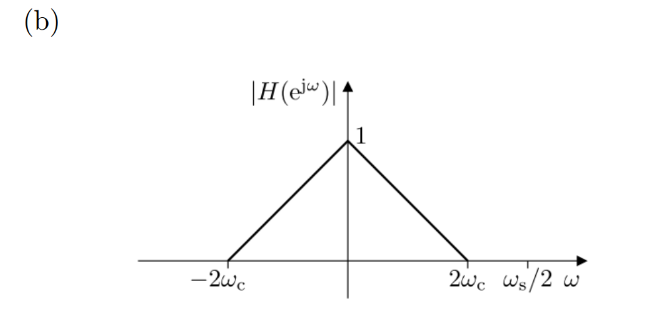

/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


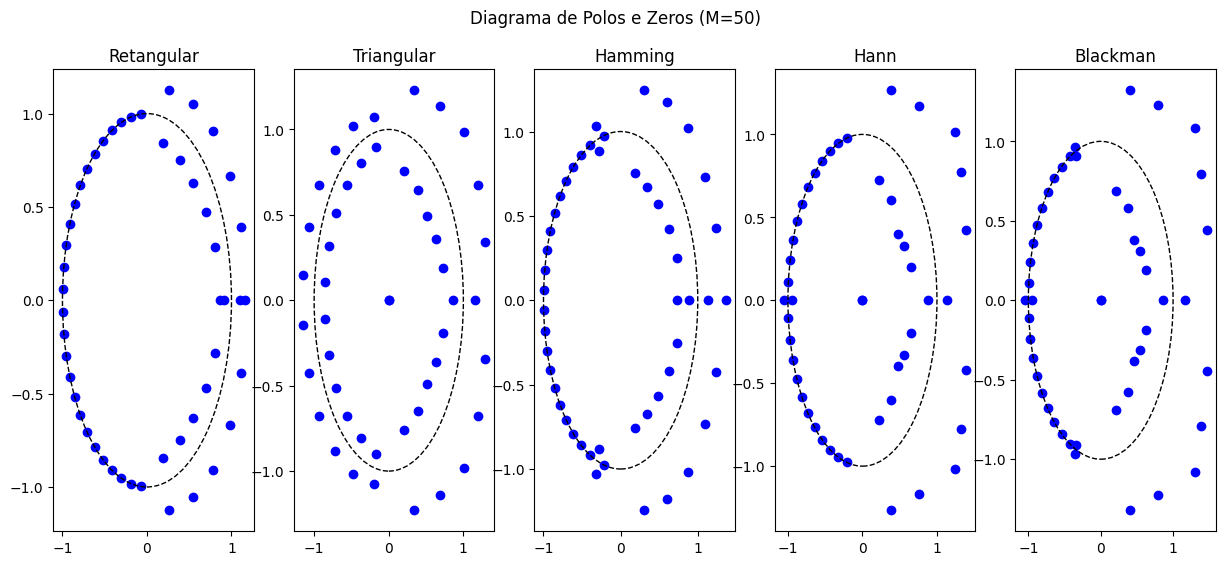

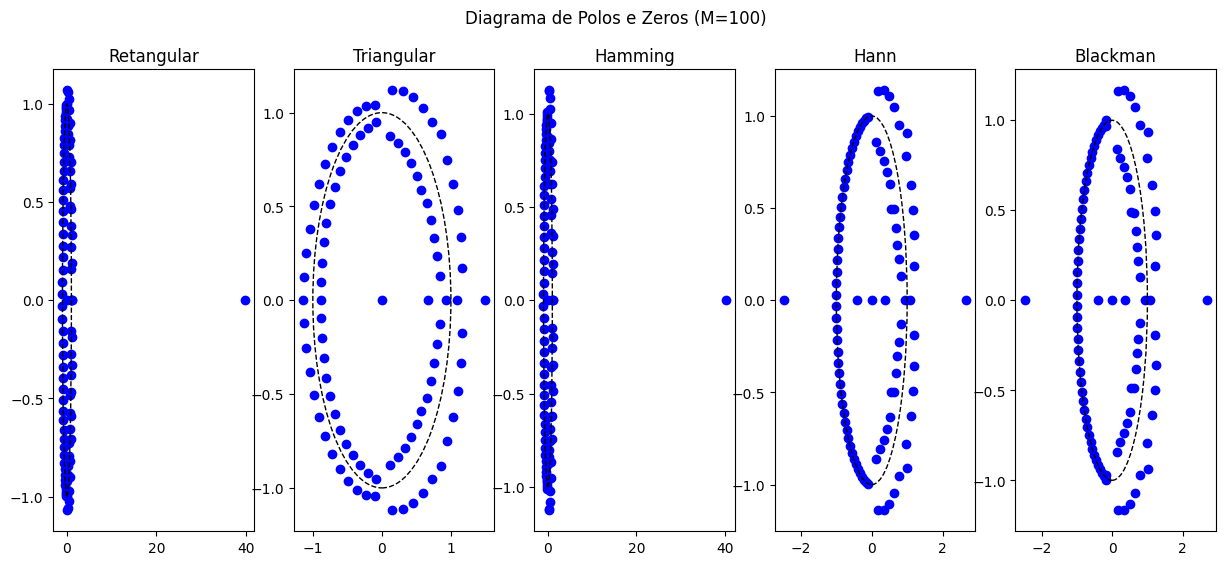

In [30]:
from scipy import signal

for M in ordens:
    plt.figure(figsize=(15, 6))
    for i, (nome, h) in enumerate(filtros[M].items(), 1):
        plt.subplot(1, 5, i)
        z, p, k = signal.tf2zpk(h, 1)
        plt.scatter(np.real(z), np.imag(z), marker='o', color='blue', label='Zeros')
        plt.gca().add_patch(plt.Circle((0,0), 1, fill=False, linestyle='--'))
        plt.title(nome)
    plt.suptitle(f'Diagrama de Polos e Zeros (M={M})')
    plt.show()

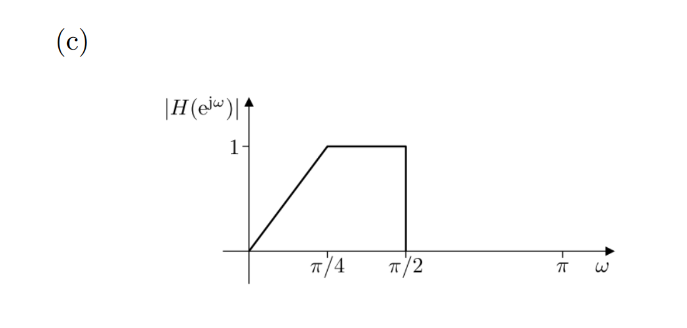

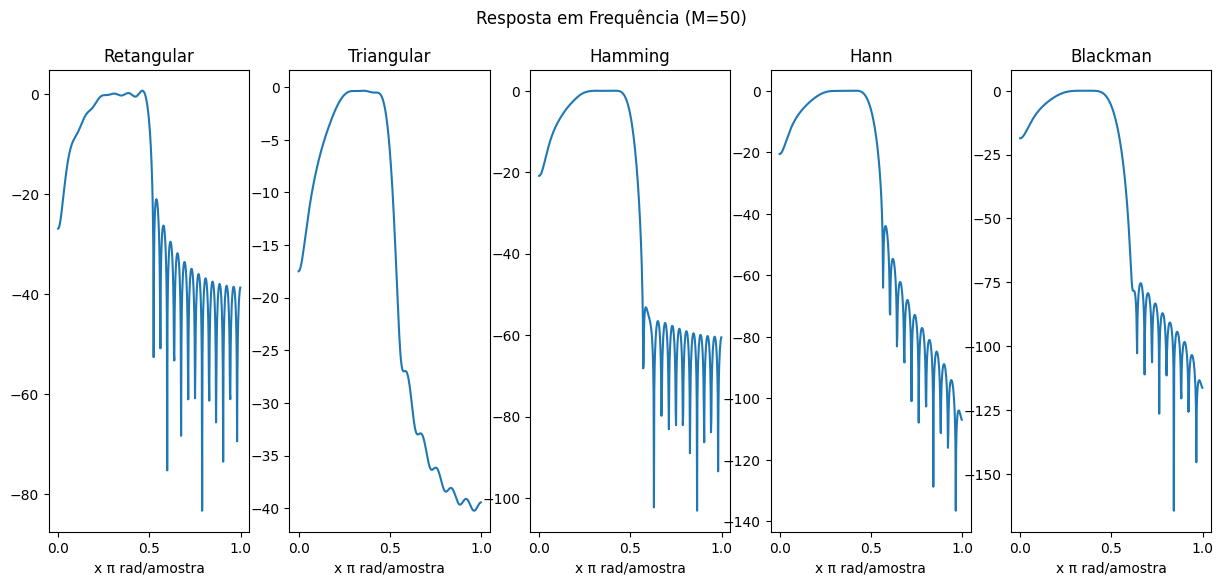

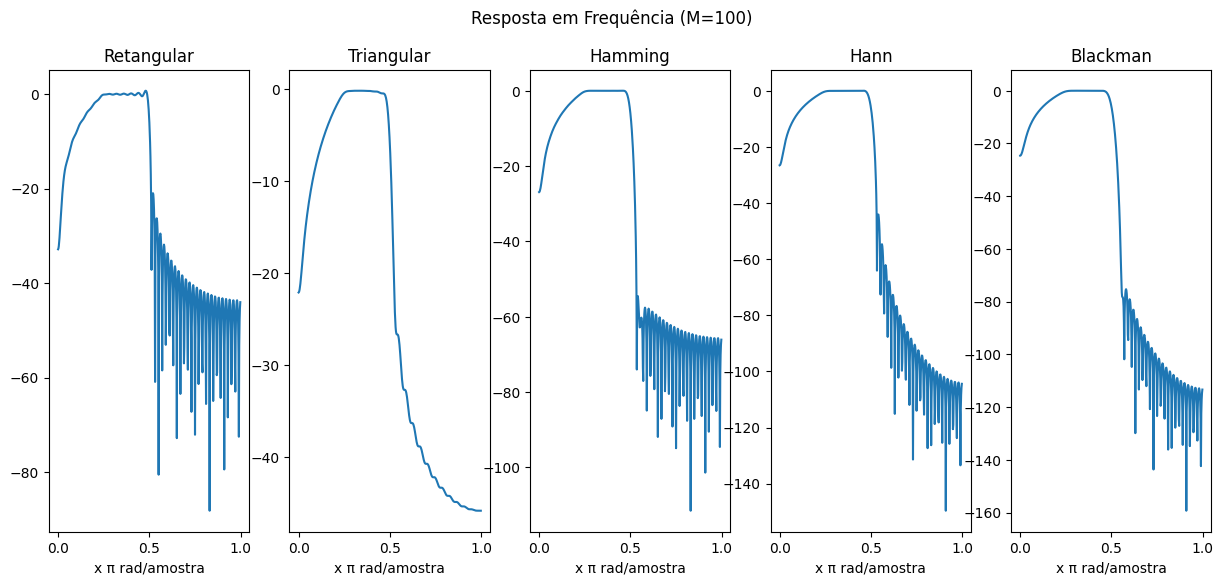

In [31]:
for M in ordens:
    plt.figure(figsize=(15, 6))
    for i, (nome, h) in enumerate(filtros[M].items(), 1):
        plt.subplot(1, 5, i)
        w, H = signal.freqz(h)
        plt.plot(w/np.pi, 20 * np.log10(np.abs(H) + 1e-10))
        plt.title(nome)
        plt.xlabel('x π rad/amostra')
    plt.suptitle(f'Resposta em Frequência (M={M})')
    plt.show()